##***Threshold Tuning***

In [ ]:
y_proba_final = best_xgb_B.predict_proba(X_test_B)[:, 1]

In [ ]:
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

threshold_results = []

for threshold in thresholds:
    y_pred_thresh = (y_proba_final >= threshold).astype(int)

    threshold_results.append({
        'Threshold': threshold,
        'Accuracy': round(accuracy_score(y_test_b, y_pred_thresh), 4),
        'Precision': round(precision_score(y_test_b, y_pred_thresh), 4),
        'Recall': round(recall_score(y_test_b, y_pred_thresh), 4),
        'F1_Score': round(f1_score(y_test_b, y_pred_thresh), 4)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df.sort_values(by='F1_Score', ascending=False)

,Threshold,Accuracy,Precision,Recall,F1_Score
6,0.60,0.9718,0.9898,0.8083,0.8899
3,0.45,0.9706,0.9798,0.8083,0.8858
4,0.50,0.9706,0.9798,0.8083,0.8858
5,0.55,0.9706,0.9798,0.8083,0.8858
2,0.40,0.9671,0.9510,0.8083,0.8739
1,0.35,0.9624,0.9151,0.8083,0.8584
0,0.30,0.9553,0.8661,0.8083,0.8362


Threshold tuning was conducted to evaluate the tradeoff between churn capture and false positive reduction. Across tested thresholds, recall remained unchanged, indicating that the same churn-prone customers were consistently identified by the model. Since lowering the threshold only reduced precision without improving churn capture, a threshold of 0.60 was selected as the optimal decision boundary.

**Best threshold - 0.60**

In [ ]:
best_threshold = 0.60

y_pred_final = (y_proba_final >= best_threshold).astype(int)

In [ ]:
auc_custom = roc_auc_score(y_test_b, y_pred_final)
print(f"ROC AUC based on 0.60 threshold: {auc_custom:.4f}")

ROC AUC based on 0.60 threshold: 0.9035


In [ ]:
print("Final Classification Report at Threshold = 0.60")
print(classification_report(y_test_b, y_pred_final))

Final Classification Report at Threshold = 0.60
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       730
           1       0.99      0.81      0.89       120

    accuracy                           0.97       850
   macro avg       0.98      0.90      0.94       850
weighted avg       0.97      0.97      0.97       850



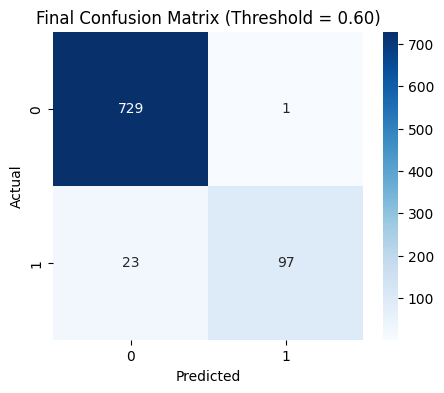

In [ ]:
cm_final = confusion_matrix(y_test_b, y_pred_final)

plt.figure(figsize=(5,4))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues')
plt.title('Final Confusion Matrix (Threshold = 0.60)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()